# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [36]:

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [37]:


start_date = '2023-01-01'# Definir o período
end_date = '2024-06-28'

# Download dos dados
tickers = ['^BVSP', 'PETR4.SA']
data_raw = yf.download(tickers, start=start_date, end=end_date)

# Extrair os preços de fechamento (usar 'Close' se 'Adj Close' não estiver disponível)
if 'Adj Close' in data_raw.columns.get_level_values(0):
    data = data_raw['Adj Close'].copy()
else:
    data = data_raw['Close'].copy()

# Renomear colunas
data.columns = ['IBVESP', 'PETR4']



[*********************100%***********************]  2 of 2 completed


cor	significado provável

roxo	período de preço intermediário

verde	período de preço mais alto

amarelo	período de preço mais baixo

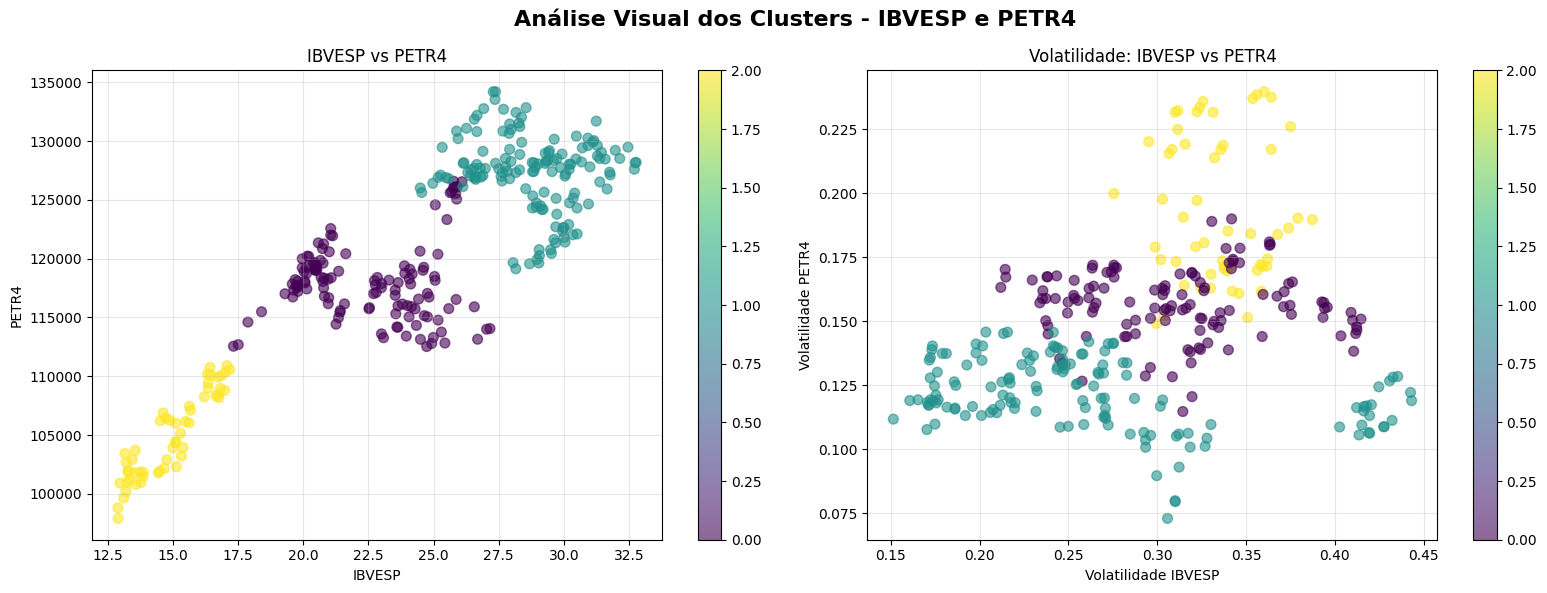

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise Visual dos Clusters - IBVESP e PETR4', fontsize=16, fontweight='bold')


scatter1 = axes[0].scatter(df_features['IBVESP'], df_features['PETR4'], c=df_features['Cluster'], cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel('IBVESP')
axes[0].set_ylabel('PETR4')
axes[0].set_title('IBVESP vs PETR4')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])# Gráfico 1: Preços 


scatter2 = axes[1].scatter(df_features['IBVESP_VOL'], df_features['PETR4_VOL'], c=df_features['Cluster'], cmap='viridis', alpha=0.6, s=50)
axes[1].set_xlabel('Volatilidade IBVESP')
axes[1].set_ylabel('Volatilidade PETR4')
axes[1].set_title('Volatilidade: IBVESP vs PETR4')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])# Gráfico 2: Volatilidade 

plt.tight_layout()
plt.show()